In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


In [2]:
df = pd.read_csv(os.path.join("..", "lindseym", "micro_events_cleaned.csv"))

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847019 entries, 0 to 847018
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   microevent_id        847019 non-null  int64  
 1   subject_id           847019 non-null  int64  
 2   hadm_id              325198 non-null  float64
 3   micro_specimen_id    847019 non-null  int64  
 4   spec_itemid          847019 non-null  int64  
 5   spec_type_desc       847019 non-null  object 
 6   test_itemid          847019 non-null  int64  
 7   test_name            847019 non-null  object 
 8   org_itemid           847019 non-null  int64  
 9   org_name             847019 non-null  object 
 10  isolate_num          847019 non-null  int64  
 11  ab_itemid            847019 non-null  int64  
 12  ab_name              847019 non-null  object 
 13  dilution_comparison  828753 non-null  object 
 14  dilution_value       828753 non-null  float64
 15  interpretation   

In [4]:
urine_samples = df[df["spec_itemid"] == 70079]

In [5]:
urine_samples.head()


,microevent_id,subject_id,hadm_id,micro_specimen_id,spec_itemid,spec_type_desc,test_itemid,test_name,org_itemid,org_name,isolate_num,ab_itemid,ab_name,dilution_comparison,dilution_value,interpretation,org_group
0,20,10000032,NaN,159861,70079,URINE,90039,URINE CULTURE,80053,enterococcus sp.,1,90004,AMPICILLIN,<=,2.0,S,Enterococcus species
1,21,10000032,NaN,159861,70079,URINE,90039,URINE CULTURE,80053,enterococcus sp.,1,90010,NITROFURANTOIN,<=,16.0,S,Enterococcus species
2,22,10000032,NaN,159861,70079,URINE,90039,URINE CULTURE,80053,enterococcus sp.,1,90011,TETRACYCLINE,=>,16.0,R,Enterococcus species
3,23,10000032,NaN,159861,70079,URINE,90039,URINE CULTURE,80053,enterococcus sp.,1,90015,VANCOMYCIN,=,1.0,S,Enterococcus species
20,142,10000826,20032235.0,8423185,70079,URINE,90039,URINE CULTURE,80002,escherichia coli,1,90004,AMPICILLIN,<=,2.0,S,Escherichia coli


In [6]:
unique_organisms = urine_samples["org_name"].unique()
print(unique_organisms)


['enterococcus sp.' 'escherichia coli' 'enterococcus faecium'
 'pseudomonas aeruginosa' 'staphylococcus, coagulase negative'
 'enterococcus faecalis' 'klebsiella pneumoniae'
 'citrobacter freundii complex' 'proteus mirabilis' 'staph aureus coag +'
 'enterobacter cloacae' 'enterobacter aerogenes' 'serratia marcescens'
 'enterobacter cloacae complex' 'klebsiella oxytoca' 'morganella morganii'
 'providencia stuartii' 'acinetobacter baumannii' 'citrobacter koseri'
 'corynebacterium urealyticum sp. nov.' 'acinetobacter baumannii complex'
 'providencia rettgeri' 'citrobacter amalonaticus' 'proteus vulgaris'
 'hafnia alvei' 'stenotrophomonas maltophilia' 'enterobacteriaceae'
 'streptococcus mitis/oralis' 'proteus penneri'
 'beta streptococcus group b' 'staphylococcus epidermidis'
 'pseudomonas putida' 'staphylococcus lugdunensis'
 'staphylococcus haemolyticus'
 'staphylococcus, coagulase negative, presumptively not s. saprophyticus'
 'achromobacter sp.' 'non-fermenter, not pseudomonas aerugin

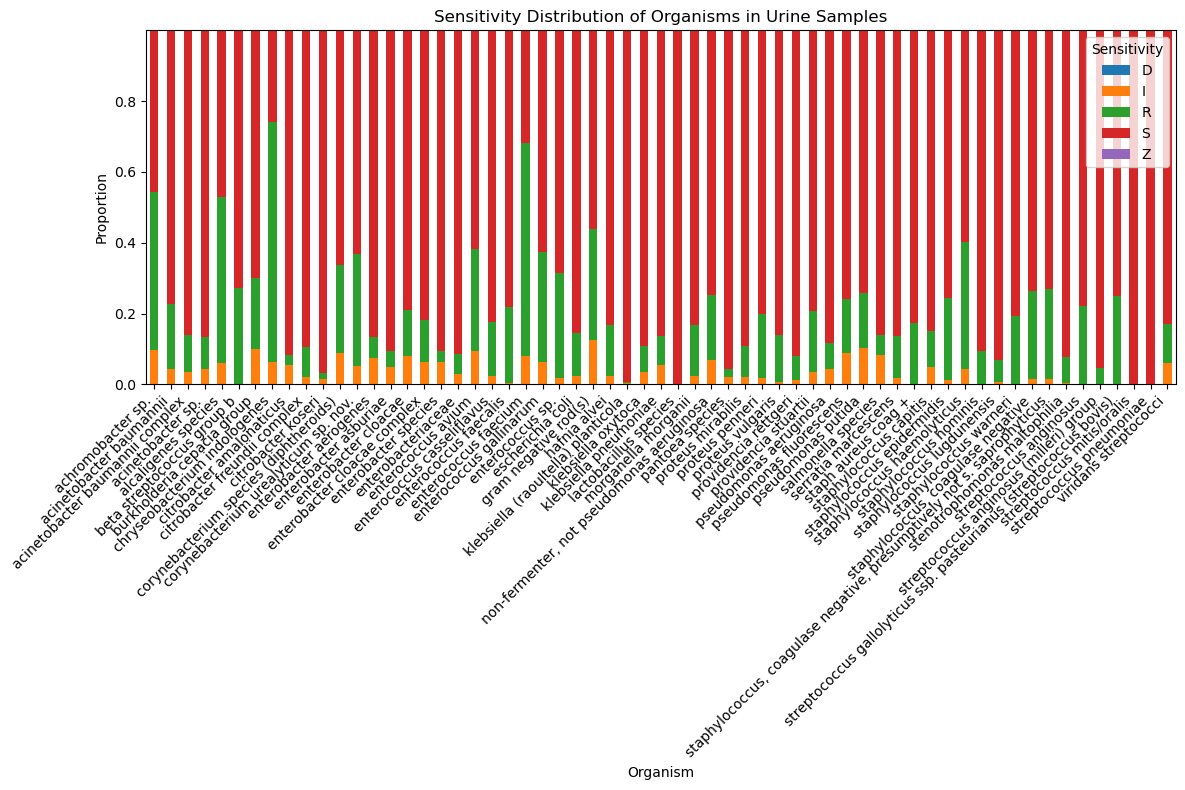

In [7]:

sensitivity_stats = urine_samples.groupby("org_name")["interpretation"].value_counts(normalize=True).unstack().fillna(0)
sensitivity_stats.plot(kind="bar", stacked=True, figsize=(12, 8))
plt.title("Sensitivity Distribution of Organisms in Urine Samples")
plt.xlabel("Organism")
plt.ylabel("Proportion")
plt.legend(title="Sensitivity", loc="upper right")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

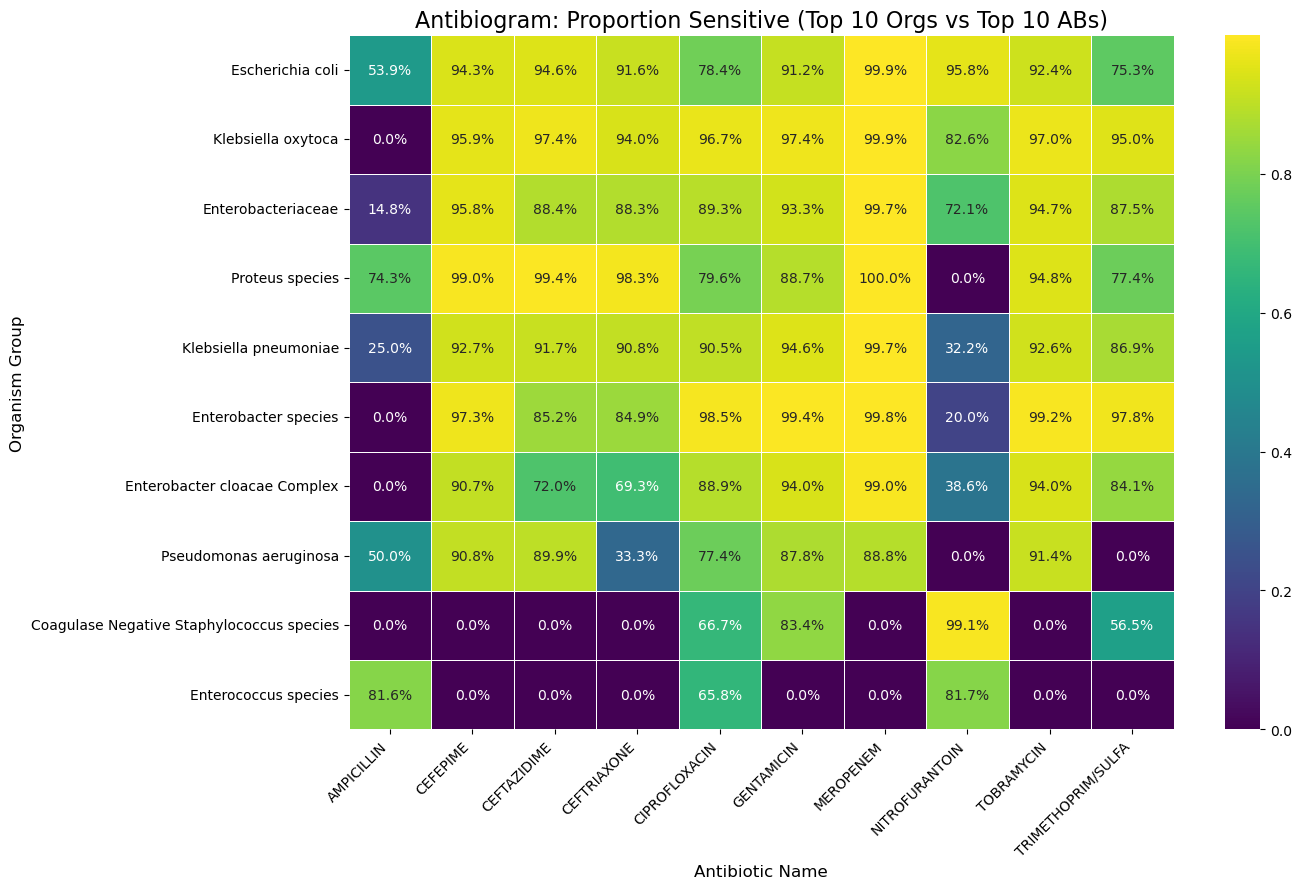

In [8]:
top_orgs = urine_samples["org_group"].value_counts().nlargest(10).index
top_abs = urine_samples["ab_name"].value_counts().nlargest(10).index

# 2. Filter
filtered_df = urine_samples[
    urine_samples["org_group"].isin(top_orgs) & 
    urine_samples["ab_name"].isin(top_abs)
].copy()

# 3. Create a boolean 'is_sensitive' column to make calculations safer
filtered_df['is_sensitive'] = (filtered_df['interpretation'] == 'S').astype(int)

# 4. Pivot Table: calculates the mean of 1s and 0s (which is the proportion)
heatmap_matrix = filtered_df.pivot_table(
    index="org_group", 
    columns="ab_name", 
    values="is_sensitive", 
    aggfunc="mean"
).fillna(0)

# 5. Optional: Sort by most sensitive organism to make the plot "cleaner"
heatmap_matrix = heatmap_matrix.loc[heatmap_matrix.mean(axis=1).sort_values(ascending=False).index]

# 6. Plot
plt.figure(figsize=(14, 9))
sns.heatmap(
    heatmap_matrix, 
    annot=True, 
    fmt=".1%", # Displays as percentage (e.g., 85.0%)
    cmap="viridis", 
    linewidths=.5
)

plt.title("Antibiogram: Proportion Sensitive (Top 10 Orgs vs Top 10 ABs)", fontsize=16)
plt.xlabel("Antibiotic Name", fontsize=12)
plt.ylabel("Organism Group", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#to save the figure, uncomment the line below and specify the path
#plt.savefig("antibiogram_heatmap.png", dpi=300)
plt.show()